# HW5 Assigned Problems

In [15]:
# As always, we start with our favorite standard imports. 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
%matplotlib inline

import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

## Homework 5 Spring 2026

- **Question 1 (39 points)** For this question, you will use the [polynomial toy data set](../DataSets/DataSets.md#polynomial-toy-data-set) from the course webpage. This is a very simple data set, you will just predict `y` using `X`. We've learned three models in class this week.
  - (A) Polynomial Regression 
  - (B) Step Functions 
  - (C) Cubic splines 

  For each of these, do the following. 
  - (i) Identify the hyperparameter that is relevant to be chosen in that model (degree, number of cuts, etc.).  
  - (ii) Use k-fold CV to find the best choice of that hyperparameter. 
  - (iii) Train the model on all of the data using that chosen hyperparameter. 
  
  Finally, make a plot of the data, along with all three of the learned models plotted on top. What do you notice? Is one a better (or worse choice) than the others? Which would you choose and why? 

- **Question 2 (26 points)**
  - Part A (13 points). I am learning a step function of some data, and I'm using knots $c_1 = 3$ and $c_2 = 7$. 
    - (i) Write equations for each of the basis functions $C_0(X)$, $C_1(X)$, and $C_2(X)$. Sketch the three functions.
    - (ii) If the model learned was 
      
      $$
      f(X) = \beta_0 + \beta_1C_1(X) + \beta_2C_2(X)
      $$
      
      with $\beta_0 = 2$, $\beta_1 = 3$, and $\beta_2 = -1$, sketch the graph learned.
  - Part B (13 points).
    - I am learning a cubic spline of some data with a single knot at $c_1 = 4$. As noted in class and in Sec 7.4.3, we have a basis for learning cubic spline data. *(As a side note, my lectures have knots as $c_1,\cdots,c_K$ and the book uses $\xi_1, \cdots, \xi_K$ but they're the same thing.)* I'm going to build a cubic spline with basis functions 
      - $b_1(X) = X$  
      - $b_2(X) = X^2$  
      - $b_3(X) = X^3$  
      - $b_4(X) =h(x,4)= \begin{cases} (x-4)^3 & x >4 \\ 0 & \text{else} \end{cases}$  
    - Assume the learned model was 
      
      $$ f(X) = 3 + b_1(X) - 2 b_2(X) + 3 b_3(X) - 4b_4(X)$$
    
    - (i) Write the equation for the piecewise polynomial that this function represents. Draw a graph of the function.
    - (ii) What are the requirements for a piecewise polynomial function to be a cubic spline?
    - (iii) Check that your piecewise polynomial from (i) fits these requirements.

### Grading distribution 

(39 + 26 = 65 points)

## Question 1. 


### Generating fake data 

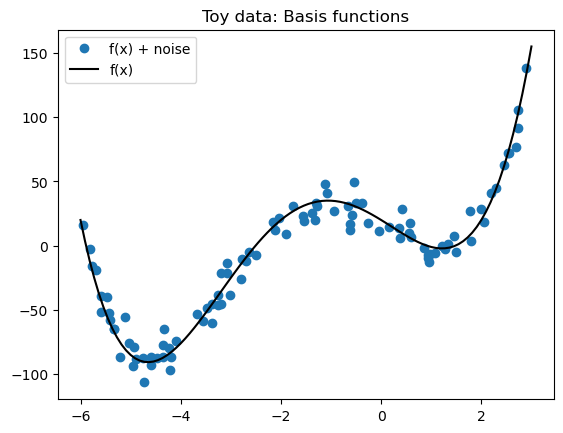

In [109]:
# Set the random seed for reproducibility
np.random.seed(42)

# Define the polynomial
f = lambda x: (x+2)*(x-2)*(x+6)*x+20

# Generate data 
x_data = np.random.uniform(-6, 3, 100)
y_data = f(x_data) + np.random.normal(0, 10, size=x_data.shape)

# Generate data for plotting 
x_plot = np.linspace(-6, 3, 100)
y_plot = f(x_plot)

# Create a DataFrame to store the data
toy_data = pd.DataFrame({'x': x_data, 'y': y_data})

plt.plot(x_data,y_data, 'o', label = 'f(x) + noise')
plt.plot(x_plot, y_plot, 'k', label = 'f(x)')
plt.legend()
plt.title('Toy data: Basis functions')

# plt.savefig('../../DataSets/polynomial-toydata.png')
plt.show()

# toy_data.to_csv('../../DataSets/polynomial-toydata.csv')

### Loading in and doing the problem from scratch to be sure

In [110]:
# First, we're going to do all the data loading we've had for a while for this data set
url = "https://msu-cmse-courses.github.io/CMSE381-S26/_downloads/f642ded4bf0e8536ccd7675bb8d41449/polynomial-toydata.csv"
polydf = pd.read_csv(url, index_col=0)
polydf.head()

,x,y
0,-2.629139,-4.940311
1,2.556429,72.467439
2,0.587945,6.763137
3,-0.612074,12.080070
4,-4.595832,-92.688351


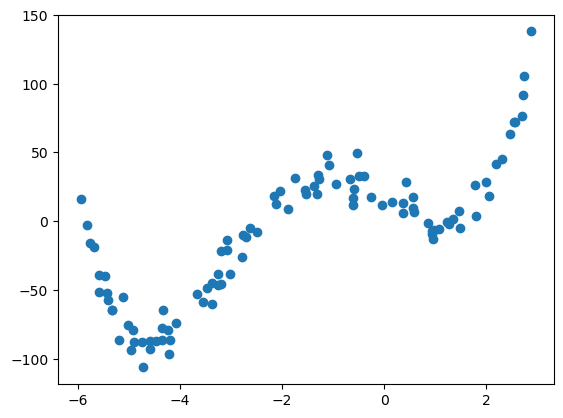

In [111]:
plt.scatter(polydf['x'], polydf['y'])
plt.show()

In [112]:
X = polydf['x'].values.reshape(-1,1)
y = polydf['y']

In [113]:
# Set t_plot for everything 
t_plot = np.linspace(-6, 3, 100).reshape(-1,1)

### (A) Polynomial Regression (13 points)

&#9989; **<font color=red>Do this:</font>** 
- (i) (3 points) Identify the hyperparameter that needs to be selected in the model (e.g., degree, number of cuts, etc.). In this case, the hyperparameter to tune is the degree of the polynomial.

In [114]:
###YOUR CODE HERE###

&#9989; **<font color=red>Do this:</font>**
- (ii) (4 points) Use k-fold CV to find the best choice of that hyperparameter.

In [116]:
##YOUR CODE HERE###

&#9989; **<font color=red>Do this:</font>**
- (iii) (3 points) Train the model on all of the data using that chosen hyperparameter. 

In [1]:
###YOUR CODE HERE###

#### ✅ Question (A-b): Documenting Your Solution Process (3 points)

Please answer the following clearly and completely:

1. **Prior Knowledge vs. External Resources (1 point)**  
   Indicate which parts of Question (A) you completed using your own prior knowledge, and which parts you completed using external resources (e.g., generative AI, past assignments, Stack Overflow, Google, etc.).

In [2]:
###YOUR ANSWER HERE###

2. **Required Documentation (2 points)**  
   - For any part where you used **generative AI**, you must include the exact prompts you entered and the corresponding AI outputs. **Copy and paste them directly**.  
   - For any part where you used other external resources, list those sources.  
   - For parts completed without external resources, briefly state what prior knowledge you relied on (no detailed explanation required).

Responses that do not include **prompts and AI outputs** (when applicable) will not receive full credit.


In [3]:
### YOUR ANSWER HERE##
#YOUR PROMPTS##

##AI OUTPUTS##

### (B) Step Functions (10 points)

&#9989; **<font color=red>Do this:</font>** 
- (i)(3 points) Identify the model hyperparameter (e.g., degree, number of cuts). Here, the hyperparameter to tune is the number of cuts in the step function.

In [4]:
###YOUR CODE HERE###

&#9989; **<font color=red>Do this:</font>**
- (ii)(4 points) Use k-fold CV to find the best choice of that hyperparameter.

In [5]:
###YOUR CODE HERE###

&#9989; **<font color=red>Do this:</font>**
- (iii) (3 points) Train the model on all of the data using that chosen hyperparameter. 

In [6]:
###YOUR CODE HERE###

### (C) Cubic spline (10 points)


&#9989; **<font color=red>Do this:</font>** 
- (i) (3 points) Identify the model hyperparameter. For a cubic spline, the hyperparameter to tune is the number of knots.

In [7]:
###YOUR CODE HERE###

&#9989; **<font color=red>Do this:</font>**
- (ii) (4 points) Use k-fold CV to find the best choice of that hyperparameter.

In [8]:
###YOUR CODE HERE###

&#9989; **<font color=red>Do this:</font>**
- (iii) (3 points) Train the model on all of the data using that chosen hyperparameter. 

In [9]:
###YOUR CODE HERE###

&#9989; **<font color=red>Do this:</font>** Show all of them together (3 points)

Create a plot of the data with all three fitted models overlaid. Describe your observations. Does one model provide a better or worse fit than the others? Which model would you select, and why?



In [11]:
###YOUR CODE AND ANSWER HERE###

&#9989; **<font color=red>Do this:</font>** Show all of them together (3 points)

Based on the above observations. Does one model provide a better or worse fit than the others? Which model would you select, and why?


In [13]:
###YOUR ANSWER HERE###

## Q2: 

### Part A (13 points). 
&#9989; **<font color=red>Do this:</font>** I am learning a step function of some data, and I'm using knots $c_1 = 3$ and $c_2 = 7$. 
- (i) (5 points) Write equations for each of the basis functions $C_0(X)$, $C_1(X)$, and $C_2(X)$. Sketch the three functions.



In [14]:
###YOUR CODE HERE##

#### ✅ Question (i-b): Documenting Your Solution Process (3 points)

Please answer the following clearly and completely:

1. **Prior Knowledge vs. External Resources (1 point)**  
   Indicate which parts of Question (i) you completed using your own prior knowledge, and which parts you completed using external resources (e.g., generative AI, past assignments, Stack Overflow, Google, etc.).

In [15]:
###YOUR ANSWER HERE###

2. **Required Documentation (2 points)**  
   - For any part where you used **generative AI**, you must include the exact prompts you entered and the corresponding AI outputs. **Copy and paste them directly**.  
   - For any part where you used other external resources, list those sources.  
   - For parts completed without external resources, briefly state what prior knowledge you relied on (no detailed explanation required).

Responses that do not include **prompts and AI outputs** (when applicable) will not receive full credit.

In [16]:
### YOUR ANSWER HERE##
#YOUR PROMPTS##

##AI OUTPUTS##

&#9989; **<font color=red>Do this:</font>**
- (ii) (5 points) If the model learned was 
    
    $$
    f(X) = \beta_0 + \beta_1C_1(X) + \beta_2C_2(X)
    $$
    
    with $\beta_0 = 2$, $\beta_1 = 3$, and $\beta_2 = -1$, sketch the graph learned.
    

In [17]:
###YOUR CODE HERE###

### Part B (13 points).
- I am learning a cubic spline of some data with a single knot at $c_1 = 4$. As noted in class and in Sec 7.4.3, we have a basis for learning cubic spline data. *(As a side note, my lectures have knots as $c_1,\cdots,c_K$ and the book uses $\xi_1, \cdots, \xi_K$ but they're the same thing.)* I'm going to build a cubic spline with basis functions 
    - $b_1(X) = X$  
    - $b_2(X) = X^2$  
    - $b_3(X) = X^3$  
    - $b_4(X) =h(x,4)= \begin{cases} (x-4)^3 & x >4 \\ 0 & \text{else} \end{cases}$  
- Assume the learned model was 
    
    $$ f(X) = 3 + b_1(X) - 2 b_2(X) + 3 b_3(X) - 4b_4(X)$$

- (i) Write the equation for the piecewise polynomial that this function represents. Draw a graph of the function.
- (ii) What are the requirements for a piecewise polynomial function to be a cubic spline?
- (iii) Check that your piecewise polynomial from (i) fits these requirements.


&#9989; **<font color=red>Do this:</font>**
- (i) (3 points) Write the equation for the piecewise polynomial that this function represents. Draw a graph of the function.

In [18]:
###YOUR CODE HERE###

&#9989; **<font color=red>Do this:</font>**
- (ii) (4 points) What are the requirements for a piecewise polynomial function to be a cubic spline?


###YOUR ANSWER HERE##

#### ✅ Question (ii): Documenting Your Solution Process (3 points)

Please answer the following clearly and completely:

1. **Prior Knowledge vs. External Resources (1 point)**  
   Indicate which parts of Question (ii) you completed using your own prior knowledge, and which parts you completed using external resources (e.g., generative AI, past assignments, Stack Overflow, Google, etc.).

In [19]:
###YOUR ANSWER HERE###

2. **Required Documentation (2 points)**  
   - For any part where you used **generative AI**, you must include the exact prompts you entered and the corresponding AI outputs. **Copy and paste them directly**.  
   - For any part where you used other external resources, list those sources.  
   - For parts completed without external resources, briefly state what prior knowledge you relied on (no detailed explanation required).

Responses that do not include **prompts and AI outputs** (when applicable) will not receive full credit.

In [20]:
### YOUR ANSWER HERE##
#YOUR PROMPTS##

##AI OUTPUTS##

&#9989; **<font color=red>Do this:</font>**
- (iii) (3 points) Check that your piecewise polynomial from (i) fits these requirements.

In [21]:
###YOUR ANSERE HERE###